In [ ]:
#solo es necesario instalar las librerias una vez, si ya estan instaladas no es necesario volver a ejecutar este comando
%pip install pandas numpy matplotlib seaborn scikit-learn

# GRAFICOS Y ENTRENAMIENTO DE MODELOS

Variable objetivo: churn
   No churn (0): 5174 clientes (73.5%)
   Sí churn (1): 1869 clientes (26.5%)


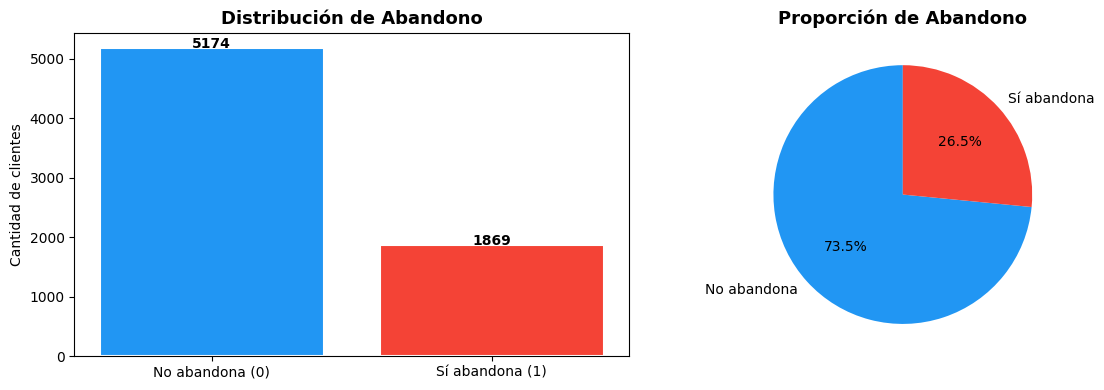

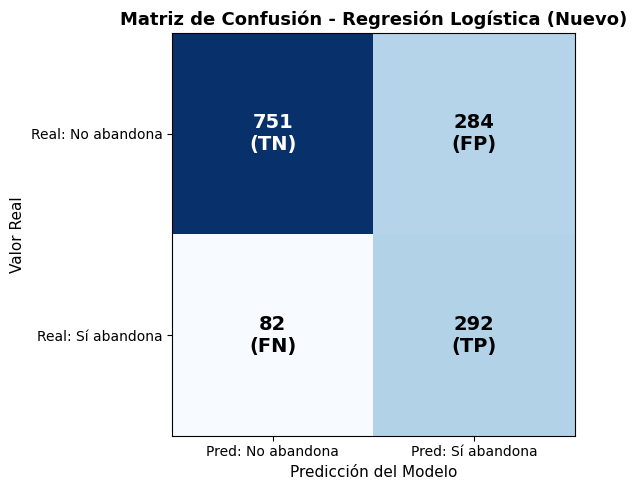

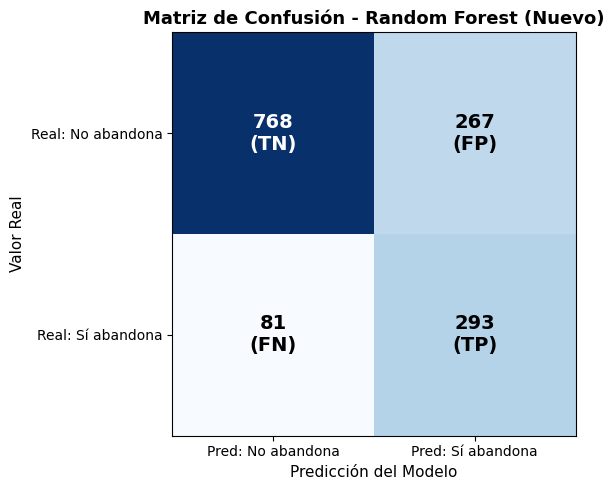

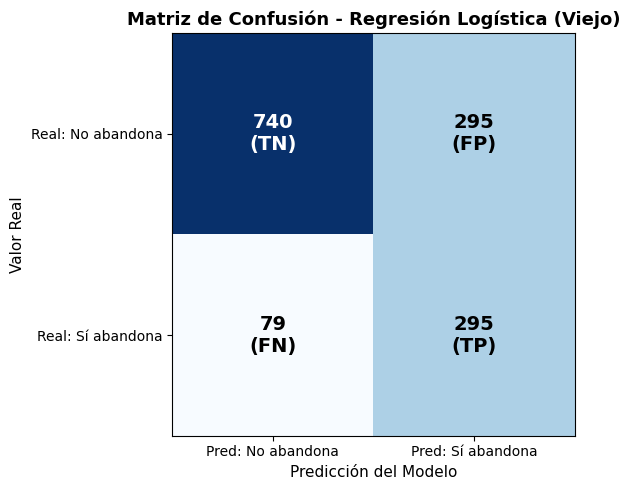

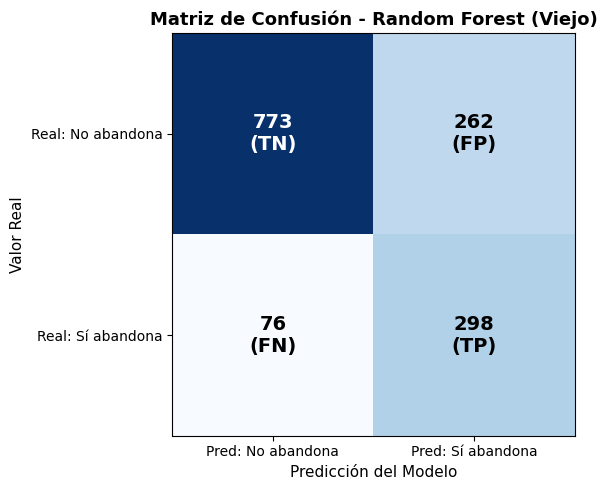

📊 COMPARACIÓN GLOBAL DE ALGORITMOS
Métrica          Reg. Logística    Reg. Log. (Vieja)    Random Forest         RF (Viejo)
--------------------------------------------------------------------------------------------------------------
Accuracy                 74.0%              73.5%           75.3% 👑          76.0%
Precision                50.7%              50.0%           52.3% 👑          53.2%
Recall                   78.1%              78.9%           78.3% 👑          79.7%
F1-Score                 61.5%              61.2%           62.7% 👑          63.8%

Métricas RF (Viejo) -> AUC: 0.843 | Gini: 0.685


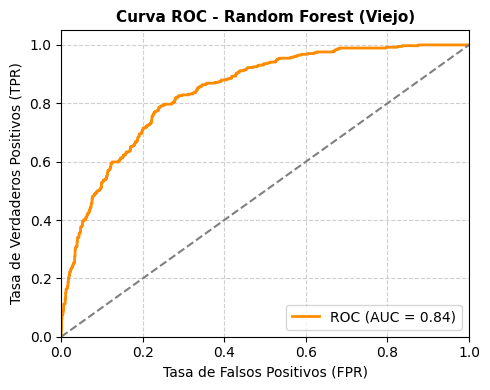

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 1. Función para entrenar y predecir
def entrenar_obtener_predicciones(modelo, X_train, y_train, X_test):
    modelo.fit(X_train, y_train)
    return modelo.predict(X_test)

# 2. Función para graficar la matriz de confusión
def graficar_matriz_confusion(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No abandona', 'Pred: Sí abandona'])
    ax.set_yticklabels(['Real: No abandona', 'Real: Sí abandona'])
    ax.set_ylabel('Valor Real', fontsize=11)
    ax.set_xlabel('Predicción del Modelo', fontsize=11)

    etiquetas = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
            
    plt.tight_layout()
    plt.show()

# 3. Cargar y preparar los datasets
# Dataset 1: Modificado/Limpio
df = pd.read_csv('../data/processed/Telco_clean.csv')
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['churn']), df['churn'], test_size=0.2, random_state=42, stratify=df['churn']
)

# Dataset 2: Viejo (con total_charges)
df2 = pd.read_csv('../data/processed/Telco_limpio.csv')
X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    df2.drop(columns=['churn']), df2['churn'], test_size=0.2, random_state=42, stratify=df2['churn']
)

conteo = df['churn'].value_counts()
pct    = df['churn'].value_counts(normalize=True) * 100

print('Variable objetivo: churn')
print(f'   No churn (0): {conteo[0]} clientes ({pct[0]:.1f}%)')
print(f'   Sí churn (1): {conteo[1]} clientes ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2196F3', '#F44336']
axes[0].bar(['No abandona (0)', 'Sí abandona (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Abandono', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['No abandona', 'Sí abandona'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción de Abandono', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Instanciar los modelos con sus parámetros óptimos
lr = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', min_samples_split=5, random_state=42)

# 5. Entrenar y obtener predicciones para cada combinación de Modelo + Dataset
y_pred_lr = entrenar_obtener_predicciones(lr, X_train, y_train, X_test)
y_pred_rf = entrenar_obtener_predicciones(rf, X_train, y_train, X_test)

y_pred_lr_old = entrenar_obtener_predicciones(lr, X_train_old, y_train_old, X_test_old)
y_pred_rf_old = entrenar_obtener_predicciones(rf, X_train_old, y_train_old, X_test_old)

# 6. Graficar Matrices de Confusión
graficar_matriz_confusion(y_test, y_pred_lr, 'Matriz de Confusión - Regresión Logística (Nuevo)')
graficar_matriz_confusion(y_test, y_pred_rf, 'Matriz de Confusión - Random Forest (Nuevo)')
graficar_matriz_confusion(y_test_old, y_pred_lr_old, 'Matriz de Confusión - Regresión Logística (Viejo)')
graficar_matriz_confusion(y_test_old, y_pred_rf_old, 'Matriz de Confusión - Random Forest (Viejo)')

# 7. Imprimir tabla comparativa final
print('📊 COMPARACIÓN GLOBAL DE ALGORITMOS')
print('=' * 110)
print(f'{"Métrica":<15} {"Reg. Logística":>15} {"Reg. Log. (Vieja)":>20} {"Random Forest":>16} {"RF (Viejo)":>18}')
print('-' * 110)

metricas_comp = {
    'Accuracy' : (accuracy_score(y_test, y_pred_lr), accuracy_score(y_test_old, y_pred_lr_old), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test_old, y_pred_rf_old)),
    'Precision': (precision_score(y_test, y_pred_lr), precision_score(y_test_old, y_pred_lr_old), precision_score(y_test, y_pred_rf), precision_score(y_test_old, y_pred_rf_old)),
    'Recall'   : (recall_score(y_test, y_pred_lr), recall_score(y_test_old, y_pred_lr_old), recall_score(y_test, y_pred_rf), recall_score(y_test_old, y_pred_rf_old)),
    'F1-Score' : (f1_score(y_test, y_pred_lr), f1_score(y_test_old, y_pred_lr_old), f1_score(y_test, y_pred_rf), f1_score(y_test_old, y_pred_rf_old)),
}

for nombre, (v1, v2, v3, v4) in metricas_comp.items():
    max_val = max(v1, v2, v3, v4)
    mejor1 = '👑' if v1 == max_val else '  '
    mejor2 = '👑' if v2 == max_val else '  '
    mejor3 = '👑' if v3 == max_val else '  '
    mejor4 = '👑' if v4 == max_val else '  '

    print(f'{nombre:<15} {mejor1}{v1*100:>11.1f}% {mejor2}{v2*100:>15.1f}% {mejor3}{v3*100:>12.1f}% {mejor4}{v4*100:>14.1f}%')

print('=' * 110)

# 8. Calcular AUC y Gini para Random Forest (Viejo)
# 8.1. Obtener probabilidades de la clase positiva (churn)
y_prob_rf_old = rf.predict_proba(X_test_old)[:, 1]

# 8.2. Calcular AUC y Gini
auc_rf_old = roc_auc_score(y_test_old, y_prob_rf_old)
gini_rf_old = (2 * auc_rf_old) - 1

print(f'\nMétricas RF (Viejo) -> AUC: {auc_rf_old:.3f} | Gini: {gini_rf_old:.3f}')

# 8.3. Graficar Curva ROC
fpr, tpr, umbrales = roc_curve(y_test_old, y_prob_rf_old)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_rf_old:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea de clasificador aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest (Viejo)', fontsize=11, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# INTERPRETACION Y CONCLUSIONES

---

## ¿Qué mide cada métrica?

| Métrica | Pregunta que responde | Resultado | Interpretación |
|---|---|---|---|
| **Accuracy** | ¿Cuántos acerté en total? | 76% | De 100 clientes, acertó 76 |
| **Precision** | Cuando digo "abandona", ¿cuántas veces tengo razón? | 53.2% | De 100 alertas, 53.2 son reales y 46.8 son falsas alarmas |
| **Recall** | De los que SÍ abandonan, ¿cuántos detecté? | 79.7% | De 100 abandonos reales, solo detecta 79.7 |
| **F1-Score** | ¿Cuál es el equilibrio entre Precision y Recall? | 63.8% | Desbalance: preciso pero poco sensible |

---

## ¿Cómo se relacionan con los errores del modelo?

| Concepto | Significado | Ejemplo en este caso |
|---|---|---|
| **Verdadero Positivo (TP)** | Predijo "abandona" y SÍ abandonó ✅ | Detectó correctamente al cliente en riesgo |
| **Verdadero Negativo (TN)** | Predijo "no abandona" y NO abandonó ✅ | Descartó correctamente a un cliente fiel |
| **Falso Positivo (FP)** | Predijo "abandona" pero NO abandonó ❌ | Falsa alarma — cliente fiel marcado como riesgo |
| **Falso Negativo (FN)** | Predijo "no abandona" pero SÍ abandonó ❌ | El más peligroso — cliente perdido sin detectar |

---

## ¿Qué tipo de error es más costoso?

| Error | Consecuencia para el negocio | Costo |
|---|---|---|
| **Falso Positivo** | Se ofrece retención a un cliente que no iba a irse | Bajo — se gasta en retención innecesaria |
| **Falso Negativo** | No se detecta un cliente que sí se va | **Alto** — se pierde el cliente sin intervenir |

> 💡 Para telecomunicaciones, **perder un cliente es más costoso** que hacer una retención innecesaria.  
> Por eso **Recall es la métrica más importante** en este problema.


---

## Diagnóstico del modelo RF(viejo)

| Aspecto | Estado | Detalle |
|---|---|---|
| Accuracy | 🟡 Aceptable | 76% — parece bueno pero el dataset está desbalanceado |
| Precision | 🔴 Bajo | 53.2% — cuando alerta, la mitad de las veces tiene razón |
| Recall | 🟢 Bueno | 79.7% — El modelo detecta a la gran mayoría de los clientes que se van |
| F1-Score | 🟡 Regular | 63.8% — refleja el desbalance entre Precision y Recall |

## ¿Qué significa el Área Bajo la Curva ROC (AUC = 84.3%)?

Si seleccionamos al azar un cliente que abandonará la empresa y otro que se quedará, hay un 84.3% de probabilidad de que el modelo clasifique al cliente que se va con un riesgo de fuga mayor que al cliente estable. Es una métrica muy robusta porque evalúa el modelo en todos los umbrales posibles, confirmando que no es un resultado por azar.

## ¿Qué significa el Coeficiente de Gini (0.685)?

Un valor de 0.685 se considera muy alto y óptimo en la industria financiera y de telecomunicaciones (donde cualquier valor sobre 0.60 ya es excelente). Significa que el modelo concentra con mucha fuerza a los clientes de alto riesgo en la parte superior de tu lista, permitiéndole al equipo de marketing dirigir las campañas de retención exactamente a quienes más lo necesitan sin perder recursos.

# ¿Qué nos dice esto?

* La Regresión Logística y el Random Forest muestran un rendimiento casi idéntico y una ventaja marginal en la Precisión a favor de Random Forest(viejo).

* Esto nos demuestra que el comportamiento de Churn en este dataset está gobernado por relaciones mayoritariamente lineales que ambos modelos logran capturar por igual, alcanzando un "techo" de aprendizaje con los datos disponibles.

* A pesar de la mínima diferencia técnica, Random Forest(viejo) sigue siendo la opción preferible para el negocio. En despliegues masivos de telecomunicaciones, un pequeño porcentaje de mejora en precisión representa la reducción de miles de falsas alarmas, optimizando el presupuesto de las campañas de retención y disminuyendo el costo operativo por cliente corregido.

# Conclusión General

Tras evaluar cuatro configuraciones distintas, el modelo de Random Forest entrenado con el dataset original (RF Viejo) demostró ser la opción óptima para el negocio, liderando en Exactitud (76.0%), Precisión (53.2%), Sensibilidad (79.7%) y F1-Score (63.8%).

### Pilares de diseño fundamentales demostrados:

* **Sensibilidad al algoritmo:** El procesamiento de datos (escalado y eliminación de colinealidad) es crítico para modelos lineales como la Regresión Logística, pero limita la capacidad de modelos no lineales como Random Forest, el cual se beneficia de mantener variables complejas como **total_charges**.
* **Impacto de Negocio:** El modelo seleccionado (**RF Viejo**) mantiene la capacidad de detectar a casi 8 de cada 10 clientes en riesgo de abandono (**79.7% Recall**), pero reduce el costo operativo de la campaña al ofrecer la mayor tasa de acierto (**53.2% Precision**), minimizando el impacto económico de los Falsos Positivos (falsas alarmas).
* **Limitación de los datos (Techo Estadístico):** A pesar de las diferencias arquitectónicas entre los algoritmos, los resultados finales convergen en rangos muy similares. Esto nos permite concluir que se ha alcanzado un "techo estadístico", donde el rendimiento no mejorará significativamente debido a las limitaciones de información del set de datos actual, sugiriendo la necesidad de incorporar nuevas variables predictoras en el futuro.